# Seminar 05 — From LLM to VLA
**Student · Google Colab · CPU**

A robot must put a carrot on a plate. How does an image-and-language model produce robot commands?
Audit action dependencies, then measure how tokenization changes recorded movements.
The real Bridge examples include other pick-and-place tasks; they do not include a carrot episode.


## 0. Environment — run first
Open this notebook in Colab and use a **CPU runtime**. Python 3.10–3.13 is supported.
Run this cell before any imports. It installs small dependencies and unpacks the embedded Bridge subset and FAST+ tokenizer.
No 7B model weights, dataset download, account or GPU is required.


In [ ]:
import importlib.util, subprocess, sys, os
from pathlib import Path
os.environ['TOKENIZERS_PARALLELISM']='false'
if not (3,10) <= sys.version_info[:2] <= (3,13):
    raise RuntimeError('Use Python 3.10–3.13.')
subprocess.run([sys.executable,'-m','pip','install','--quiet',
    'numpy==2.2.6','scipy==1.15.3','pandas==2.2.3',
    'matplotlib==3.10.3','pillow==11.3.0',
    'transformers==4.48.3','tokenizers==0.21.0','huggingface-hub==0.28.1'],check=True)
if importlib.util.find_spec('torch') is None:
    subprocess.run([sys.executable,'-m','pip','install','--quiet','torch>=2.2,<3',
        '--index-url','https://download.pytorch.org/whl/cpu'],check=True)
ROOT=Path('/content/seminar05' if Path('/content').exists() else './seminar05_runtime').resolve()
ROOT.mkdir(parents=True,exist_ok=True)
print('Runtime:',sys.version.split()[0], '| files:',ROOT)


In [ ]:
# @title Supplied data and helpers { display-mode: "form" }
import base64, hashlib, io, zipfile
BUNDLES = {'bridge': '...', 'fast': '...'}
EXPECTED_SHA256 = {'bridge': '15a1070c52a44dedab98e2d06a2211cb78b0decac90722f68785771c218558da', 'fast': '99780f6c33949f79a82c4a80a500a30e0632b0ae8d2d5d659ef4cf7570cc99cd'}
for name,encoded in BUNDLES.items():
    payload=base64.b64decode(encoded)
    assert hashlib.sha256(payload).hexdigest()==EXPECTED_SHA256[name]
    destination=ROOT/name;destination.mkdir(exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        archive.extractall(destination)
DATA=ROOT/'bridge'
FAST_DIR=ROOT/'fast'
print('Embedded archives verified and extracted.')


### Data and supplied code
BridgeData V2 **1.0.0**, official shard 0: 12 train and 8 test episodes, split by whole episode.
Actions: `[dx, dy, dz, droll, dpitch, dyaw, gripper_open]`; movement uses reached-state differences.
Translation is in **m/step**, rotation in **rad/step**, and gripper is **0 closed / 1 open**.
Drop original step 0 and the final step, as in OpenVLA `bridge_orig_dataset_transform`.
Normalize movement with train q01/q99, clip to `[-1,1]`, and leave gripper in `[0,1]`.
An event is a change in `gripper_open >= 0.5`; its time is limited to 0.2 s resolution.

Each test episode supplies two 20-step windows: low and high changes between consecutive movement commands.
We call these **smooth** and **correction**. These labels describe the signal; they do not prove the demonstrator's intent.
Shorter chunks keep the same start and 5 Hz sampling. See `MANIFEST` for source paths, hashes, selection rules and statistics.

[Dataset and attribution: Walke et al. (2023)](https://rail-berkeley.github.io/bridgedata/), CC BY 4.0.
[Action preprocessing source](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/vla/datasets/rlds/oxe/transforms.py#L61-L86).
Run the supplied helpers unchanged.


In [ ]:
# @title Supplied data and helpers { display-mode: "form" }
# Supplied teaching helpers. Embedded into both notebooks by build_notebooks.py.
import json, hashlib, importlib.util, math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

MANIFEST = json.loads((DATA / 'manifest.json').read_text())
ACTION_FILE = np.load(DATA / 'actions.npz', allow_pickle=False)
EPISODES = {r['key']: r for r in MANIFEST['episodes']}
STATS = MANIFEST['stats']
CHANNELS = MANIFEST['channels']
UNITS = MANIFEST['units']
HZ = MANIFEST['frequency_hz']
TEST_WINDOWS = MANIFEST['windows']
assert set(STATS['train_keys']).isdisjoint({k for k,r in EPISODES.items() if r['split']=='test'})
assert HZ == 5 and len(CHANNELS) == 7
np.testing.assert_allclose(np.quantile(np.concatenate([ACTION_FILE[k] for k in STATS['train_keys']]),.01,axis=0),STATS['q01'])
print(f"{len(EPISODES)} real episodes; {len(STATS['train_keys'])} train; {len(TEST_WINDOWS)} test windows; {HZ} Hz")
display(pd.DataFrame([{'episode':k,'split':r['split'],'steps':r['steps'],'instruction':r['instruction']} for k,r in EPISODES.items()]))

def normalize(a, stats, clip=True):
    lo,hi,mask = np.array(stats['q01']),np.array(stats['q99']),np.array(stats['mask'])
    span=np.maximum(hi-lo,1e-8)
    out=np.where(mask,2*(a-lo)/span-1,a)
    return np.clip(out,-1,1) if clip else out

def denormalize(a, stats):
    lo,hi,mask=np.array(stats['q01']),np.array(stats['q99']),np.array(stats['mask'])
    return np.where(mask,(a+1)/2*np.maximum(hi-lo,1e-8)+lo,a)

def scalar_encode(a, bins=256, vocab_size=32000):
    # Exact numerical operations from OpenVLA ActionTokenizer; no Llama weights required.
    edges=np.linspace(-1,1,bins)
    return vocab_size-np.digitize(np.clip(a,-1,1),edges)

def scalar_decode(ids, bins=256, vocab_size=32000):
    edges=np.linspace(-1,1,bins); centers=(edges[:-1]+edges[1:])/2
    return centers[np.clip(vocab_size-ids-1,0,len(centers)-1)]

def get_chunks(T=20):
    if T not in (5,10,20): raise ValueError('Use the prepared lengths: 5, 10, 20')
    # Same start for each length; no resampling or padding of real trajectories.
    return np.stack([ACTION_FILE[w['key']][w['start']:w['start']+T] for w in TEST_WINDOWS])

def transitions(grip):
    binary=np.asarray(grip)>=.5
    return np.flatnonzero(binary[1:]!=binary[:-1])+1

def event_metrics(truth, restored):
    a,b=truth[:,-1]>=.5,restored[:,-1]>=.5
    ta,tb=transitions(truth[:,-1]),transitions(restored[:,-1])
    return {'gripper_states_preserved':bool(np.array_equal(a,b)),
        'gripper_events_preserved':bool(np.array_equal(ta,tb)),
        'event_count':len(ta),'event_mismatches':len(set(ta)^set(tb)),
        'true_events':ta.tolist(),'decoded_events':tb.tolist()}

def reconstruction_rows(chunks, restored, stats, method, token_counts):
    raw_norm=normalize(chunks,stats,clip=False)
    clipped=denormalize(np.clip(raw_norm,-1,1),stats)
    err=np.abs(restored-chunks); quant=np.abs(restored-clipped)
    rows=[]
    for b,w in enumerate(TEST_WINDOWS):
        events=event_metrics(chunks[b],restored[b])
        for d,ch in enumerate(CHANNELS):
            rows.append({'episode':w['key'],'kind':w['kind'],'start':w['start'],
                'T':chunks.shape[1],'seconds':chunks.shape[1]/HZ,'method':method,
                'tokens':int(token_counts[b]),'scalar_tokens':chunks.shape[1]*chunks.shape[2],
                'ratio':chunks.shape[1]*chunks.shape[2]/token_counts[b],
                'channel':ch,'unit':UNITS[d],'mae':float(err[b,:,d].mean()),
                'max_error':float(err[b,:,d].max()),'quantization_mae':float(quant[b,:,d].mean()),
                'clipped_fraction':float((np.abs(raw_norm[b,:,d])>1).mean()),
                'clipping_mae':float(np.abs(clipped[b,:,d]-chunks[b,:,d]).mean()),**events})
    return rows

def show_tables(table):
    display(table.groupby(['method','T','kind','channel'],sort=False).agg(
        MAE=('mae','mean'),max_error=('max_error','max'),clipped_fraction=('clipped_fraction','mean'),
        clipping_MAE=('clipping_mae','mean'),quantization_MAE=('quantization_mae','mean')).round(6))
    chunks=table.drop_duplicates(['method','T','episode','kind','start'])
    display(chunks.groupby(['method','T','kind'],sort=False).agg(
        mean_tokens=('tokens','mean'),min_ratio=('ratio','min'),mean_ratio=('ratio','mean'),
        all_states_preserved=('gripper_states_preserved','all'),all_events_preserved=('gripper_events_preserved','all')))

def plot_reconstruction(chunks, restored, labels, indices):
    fig,axes=plt.subplots(len(indices),3,figsize=(12,3*len(indices)),squeeze=False)
    for row,b in enumerate(indices):
        t=np.arange(chunks.shape[1])/HZ
        for col,d in enumerate((0,2,6)):
            ax=axes[row,col];ax.plot(t,chunks[b,:,d],'k.-',label='Recorded')
            for values,label in zip(restored,labels):ax.plot(t,values[b,:,d],'.--',label=label,alpha=.8)
            ax.set(xlabel='Time (s)',ylabel=f'{CHANNELS[d]} ({UNITS[d]})',title=f"{TEST_WINDOWS[b]['key']} / {TEST_WINDOWS[b]['kind']}")
            if d==6:ax.axhline(.5,color='gray',lw=.7)
            ax.legend(fontsize=8)
    plt.tight_layout();plt.show()

# Display errors in readable physical units; the stored metrics keep m/step and rad/step.
DISPLAY_SCALE=np.array([1000.]*3+[180/np.pi]*3+[1.])
DISPLAY_UNITS=['mm/step']*3+['deg/step']*3+['openness']

def show_quantization_errors(table,T,filename):
    subset=table[table['T']==T]
    methods=list(subset['method'].drop_duplicates())
    mean=subset.groupby(['channel','method'])['quantization_mae'].mean().unstack().reindex(CHANNELS)[methods]
    scaled=mean.mul(DISPLAY_SCALE,axis=0)
    clipping=subset.groupby('channel')['clipping_mae'].mean().reindex(CHANNELS)*DISPLAY_SCALE
    summary=scaled.copy();summary.insert(0,'unit',DISPLAY_UNITS)
    summary['clipping MAE (shared)']=clipping
    print(f'MAE relative to the clipped input, T={T}. Clipping MAE is measured separately against recorded actions.')
    display(summary.round(5))
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    for ax,indices,title in zip(axes,[(0,1,2),(3,4,5),(6,)],['Translation','Rotation','Gripper']):
        channels=[CHANNELS[d] for d in indices]
        scaled.loc[channels].plot.bar(ax=ax,width=.75,rot=0)
        ax.set(title=title,xlabel='',ylabel=f'Quantization MAE ({DISPLAY_UNITS[indices[0]]})')
        ax.grid(axis='y',alpha=.25);ax.legend(fontsize=8)
    fig.suptitle(f'Encode/decode error after shared clipping — {T} recorded steps')
    fig.tight_layout();fig.savefig(ROOT/filename,dpi=150,bbox_inches='tight');plt.show()
    return summary

def plot_quantization_details(chunks,restored,labels,stats,filename,channel=0):
    clipped=denormalize(normalize(chunks,stats),stats)
    raw=normalize(chunks,stats,clip=False)
    values=np.stack(restored)
    spread=np.ptp(values[:,:,:,channel],axis=0)
    # Select one real, unclipped movement sample per signal type where methods differ most.
    # This is a diagnostic example; the summary above averages all test windows.
    eligible=(np.abs(raw[:,:,channel])<=1)&np.isfinite(spread)
    scale=DISPLAY_SCALE[channel];unit=DISPLAY_UNITS[channel]
    fig,axes=plt.subplots(2,3,figsize=(15,7));selected=[]
    colors=[f'C{i}' for i in range(len(restored))]
    for row,kind in enumerate(['smooth','correction']):
        candidates=[b for b,w in enumerate(TEST_WINDOWS) if w['kind']==kind]
        scores=np.where(eligible[candidates],spread[candidates],-np.inf)
        local,step=np.unravel_index(np.argmax(scores),scores.shape);b=candidates[local]
        if not np.isfinite(scores[local,step]):raise ValueError('No unclipped sample for this channel')
        t=np.arange(chunks.shape[1])/HZ;w=TEST_WINDOWS[b]
        left,point,error=axes[row]
        left.plot(t,chunks[b,:,channel]*scale,'k.-',label='Recorded',lw=1.5)
        left.plot(t,clipped[b,:,channel]*scale,color='gray',ls=':',label='Clipped input')
        for v,label,color in zip(restored,labels,colors):
            left.plot(t,v[b,:,channel]*scale,'.--',color=color,label=label,alpha=.8)
            error.plot(t,(v[b,:,channel]-clipped[b,:,channel])*scale,'.-',color=color,label=label)
        left.axvline(t[step],color='gray',ls='--',lw=.8)
        left.set(title=f"{kind}: {w['key']}, {CHANNELS[channel]}",xlabel='Time (s)',ylabel=f'Action ({unit})')
        reference=clipped[b,step,channel]*scale
        for i,(v,color) in enumerate(zip(restored,colors)):
            point.scatter(i,v[b,step,channel]*scale,color=color,s=60,zorder=3)
        point.axhline(reference,color='k',ls=':',label='Clipped input')
        point.set(xticks=np.arange(len(labels)),xticklabels=labels,
            title=f'One recorded sample at {t[step]:.1f} s',ylabel=f'Action ({unit})')
        point.ticklabel_format(axis='y',style='plain',useOffset=False)
        point.margins(y=.25);point.legend(fontsize=8)
        error.axhline(0,color='k',lw=.7);error.axvline(t[step],color='gray',ls='--',lw=.8)
        error.set(title='Decoded minus clipped input',xlabel='Time (s)',ylabel=f'Error ({unit})')
        for ax in (left,error):ax.grid(alpha=.2);ax.legend(fontsize=8)
        selected.append({'kind':kind,'episode':w['key'],'chunk_step':int(step),
            'original_step':int(w['start']+step+1),'channel':CHANNELS[channel],
            'selection':'maximum inter-method difference among unclipped samples',
            'spread':float(spread[b,step]*scale),'unit':unit})
    fig.tight_layout();fig.savefig(ROOT/filename,dpi=150,bbox_inches='tight');plt.show()
    display(pd.DataFrame(selected))
    return selected

def plot_token_counts(table,filename):
    per_chunk=table.drop_duplicates(['method','T','episode','kind','start'])
    counts=per_chunk.groupby(['T','kind','method'])['tokens'].mean().unstack()
    ax=counts.plot.bar(figsize=(10,4),rot=0)
    ax.set(xlabel='Recorded chunk length / signal type',ylabel='Mean action token count',
        title='Representation length on identical chunks')
    ax.grid(axis='y',alpha=.25);ax.figure.tight_layout()
    ax.figure.savefig(ROOT/filename,dpi=150,bbox_inches='tight');plt.show()

# Load the unmodified official FAST+ processor from the bundled, pinned source.
FAST_CONFIG=json.loads((FAST_DIR/'processor_config.json').read_text())
spec=importlib.util.spec_from_file_location('seminar05_official_fast',FAST_DIR/'processing_action_tokenizer.py')
fast_module=importlib.util.module_from_spec(spec);spec.loader.exec_module(fast_module)
from transformers import AutoTokenizer
fast_tokenizer=fast_module.UniversalActionProcessor(
    AutoTokenizer.from_pretrained(str(FAST_DIR),local_files_only=True),
    **{k:FAST_CONFIG[k] for k in ('scale','vocab_size','min_token')})
fast_tokenizer.bpe_tokenizer.clean_up_tokenization_spaces=False

def fast_roundtrip(z):
    # The official decoder catches errors and returns zeros. Verify BPE roundtrip first,
    # so a malformed stream cannot silently appear in the measurements as a valid action.
    from scipy.fft import dct
    tokens=fast_tokenizer(z)
    coefficients=np.around(dct(z,axis=1,norm='ortho')*fast_tokenizer.scale)
    expected=np.maximum(coefficients-fast_tokenizer.min_token,0).astype(int)+fast_tokenizer.min_token
    for b,ids in enumerate(tokens):
        text=fast_tokenizer.bpe_tokenizer.decode(ids,clean_up_tokenization_spaces=False)
        actual=np.array(list(map(ord,text)))+fast_tokenizer.min_token
        np.testing.assert_array_equal(actual.reshape(z.shape[1:]),expected[b])
    decoded=fast_tokenizer.decode(tokens,time_horizon=z.shape[1],action_dim=z.shape[2])
    assert decoded.shape==z.shape and np.isfinite(decoded).all()
    return tokens,decoded

# Educational observation embeddings: 4 RGB patch means + 2 instruction vectors + separator.
# These are not cached features of DINOv2, SigLIP or Llama.
H=16;D=7;T_ATTENTION=2;N_ACTION=T_ATTENTION*D;P=7;PAD=2
rng=np.random.default_rng(17)
RGB_PROJECTOR=torch.tensor(rng.normal(size=(3,H))*.15,dtype=torch.float64)
TEXT_TABLE=torch.tensor(rng.normal(size=(256,H))*.1,dtype=torch.float64)

def observation_embeddings(key,start):
    rgb=np.asarray(Image.open(DATA/f'{key}_{start:03d}.jpg').resize((2,2)),dtype=float)/255
    image=torch.tensor(rgb.reshape(4,3),dtype=torch.float64)@RGB_PROJECTOR
    instruction=EPISODES[key]['instruction'].encode('utf-8')
    parts=[instruction[::2],instruction[1::2]]
    text=torch.stack([TEXT_TABLE[list(part)].mean(0) for part in parts])
    return torch.cat([image,text,torch.zeros(1,H,dtype=torch.float64)])

class TinyAttention(nn.Module):
    def __init__(self):
        super().__init__()
        gen=torch.Generator().manual_seed(42)
        self.register_buffer('weights',torch.randn(2,3,H,H,generator=gen,dtype=torch.float64)/math.sqrt(H))
        # Positional signal makes zero action placeholders distinct. This is a surrogate for RoPE.
        pos=torch.arange(P+N_ACTION+PAD,dtype=torch.float64)[:,None]
        dim=torch.arange(H,dtype=torch.float64)[None,:]
        self.register_buffer('positions',.1*torch.sin(pos/(10**(dim/H))))
    def forward(self,x,allowed):
        h=x+self.positions[:len(x)]
        valid_queries=allowed.any(-1)
        for weight in self.weights:
            q,k,v=[h@w for w in weight]
            logits=q@k.T/math.sqrt(H)
            prob=torch.softmax(logits.masked_fill(~allowed,-1e30),dim=-1)
            h=(h+prob@v)*valid_queries[:,None]
        return h

BLOCK=TinyAttention().eval()
valid=torch.tensor([True]*(P+N_ACTION)+[False]*PAD)

def causal_mask(valid):
    return torch.ones(len(valid),len(valid),dtype=torch.bool).tril() & valid[:,None] & valid[None,:]

def action_embeddings(actions):
    # Continuous values identify toy action inputs; no actual Llama action-token embedding is loaded.
    flat=torch.tensor(actions.reshape(-1),dtype=torch.float64)
    return flat[:,None]*torch.linspace(.2,1.1,H,dtype=torch.float64)[None,:]

W=TEST_WINDOWS[1]
OBS=observation_embeddings(W['key'],W['start'])
# TARGET uses the same episode/window as OBS.
TARGET=normalize(ACTION_FILE[W['key']][W['start']:W['start']+T_ATTENTION],STATS)

def make_inputs(target,placeholders):
    a=torch.zeros(N_ACTION,H,dtype=torch.float64) if placeholders else action_embeddings(target)
    return torch.cat([OBS,a,torch.zeros(PAD,H,dtype=torch.float64)])

def changed_rows(before,after):
    return (after-before).norm(dim=-1).detach().numpy()

def plot_masks(masks):
    fig,axes=plt.subplots(1,len(masks),figsize=(5*len(masks),4),squeeze=False)
    for ax,(name,mask) in zip(axes[0],masks.items()):
        ax.imshow(mask.numpy(),vmin=0,vmax=1,cmap='Greys');ax.axvline(P-.5,color='tab:blue');ax.axhline(P-.5,color='tab:blue')
        ax.set(xlabel='Key/input position',ylabel='Query/output position',title=name)
    plt.tight_layout();plt.show()

class SuppliedContinuousHead(nn.Module):
    # One MLP per timestep after grouping D action positions. Mirrors OFT grouping, with small dimensions.
    def __init__(self):
        super().__init__();torch.manual_seed(3)
        self.mlp=nn.Sequential(nn.Linear(D*H,H),nn.ReLU(),nn.Linear(H,D)).double()
    def forward(self,hidden):
        return self.mlp(hidden[P:P+N_ACTION].reshape(T_ATTENTION,D*H))

CONTINUOUS_HEAD=SuppliedContinuousHead().eval()


In [ ]:
example=TEST_WINDOWS[1]
display(Image.open(DATA/f"{example['key']}_{example['start']:03d}.jpg"))
print(EPISODES[example['key']]['instruction'])
print('Original source:',EPISODES[example['key']]['source_file_path'])
print('Standardized action indices:',example['start'], 'to',example['start']+19)
print('Source RGB index:',example['start']+1)


## 1. OpenVLA and OFT — where do action dependencies enter?
**OpenVLA:** DINOv2 and SigLIP encode the same image. Their patch features are fused and projected into Llama's embedding size.
Image embeddings and the instruction condition the LLM. Its LM head predicts one action token at a time.
Seven decoded values form one robot command. Training uses shifted next-token cross-entropy; execution generates tokens sequentially.


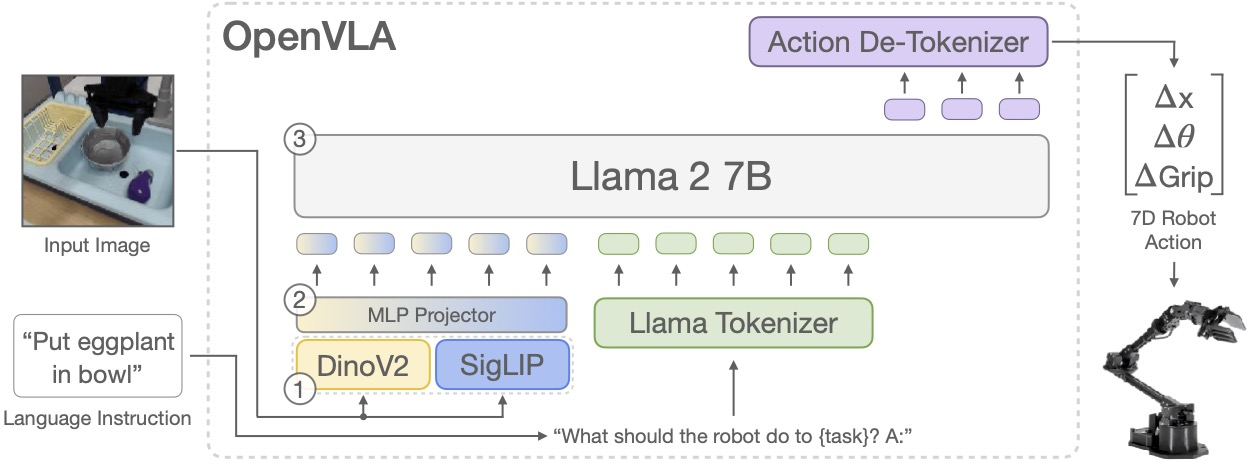

OpenVLA model overview, Kim et al. (2024). Original figure reproduced from the source; no redrawing. [Source](https://openvla.github.io/).


[Pinned source, lines 365–386](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/extern/hf/modeling_prismatic.py#L365-L386)

```python
# Visual Feature Extraction
patch_features = self.vision_backbone(pixel_values)

# Projection Logic =>> Update Attention Mask
projected_patch_embeddings = self.projector(patch_features)
projected_patch_attention_mask = None
if attention_mask is not None:
    projected_patch_attention_mask = torch.full(
        (projected_patch_embeddings.shape[0], projected_patch_embeddings.shape[1]),
        fill_value=True,
        dtype=attention_mask.dtype,
        device=attention_mask.device,
    )

# Get Input Embeddings (from Language Model Embeddings)
input_embeddings = self.get_input_embeddings()(input_ids)

# Build Multimodal Embeddings & Attention Mask =>> Prismatic defaults to inserting after <BOS> token (1:)
multimodal_embeddings = torch.cat(
    [input_embeddings[:, :1, :], projected_patch_embeddings, input_embeddings[:, 1:, :]], dim=1
)
multimodal_attention_mask = None
```


[Pinned source, lines 506–526](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/extern/hf/modeling_prismatic.py#L506-L526)

```python
def predict_action(
    self, input_ids: Optional[torch.LongTensor] = None, unnorm_key: Optional[str] = None, **kwargs: str
) -> np.ndarray:
    """Thin wrapper around .generate() that decodes predicted actions and unnormalizes them."""
    # If the special empty token ('') does not already appear after the colon (':') token in the prompt
    # (after "OUT:" or "ASSISTANT:"), insert it to match the inputs seen at training time
    if not torch.all(input_ids[:, -1] == 29871):
        input_ids = torch.cat(
            (input_ids, torch.unsqueeze(torch.Tensor([29871]).long(), dim=0).to(input_ids.device)), dim=1
        )

    # Run VLA inference
    generated_ids = self.generate(input_ids, max_new_tokens=self.get_action_dim(unnorm_key), **kwargs)

    # Extract predicted action tokens and translate into (normalized) continuous actions
    predicted_action_token_ids = generated_ids[0, -self.get_action_dim(unnorm_key) :].cpu().numpy()
    discretized_actions = self.vocab_size - predicted_action_token_ids
    discretized_actions = np.clip(discretized_actions - 1, a_min=0, a_max=self.bin_centers.shape[0] - 1)
    normalized_actions = self.bin_centers[discretized_actions]

    # Unnormalize actions
```


### Read the architecture through these operations
`vision_backbone → projector` supplies image embeddings. The multimodal concatenation inserts them after the first text token.
`language_model` processes this sequence; `predict_action` calls `generate` for seven action values and decodes the resulting IDs.
Extending scalar tokenization to `[T,7]` would require `7T` generated action tokens. This does not turn the base checkpoint into a chunk policy.

Our compact block has two attention layers and fixed random weights. Image inputs are four RGB patch means; language inputs are averaged byte embeddings.
They are **teaching substitutes**, not saved VLM features. The numerical probes measure access to inputs, not robot performance.


### TO DO 1.1 — detect target leakage
In the toy teacher-forcing sequence, the separator is at `P-1` and target token `a[j]` is fed at `P+j`.
The output at **`P-1+j` predicts `a[j]`**. It must not see that token during training.

Implement `audit_action_dependencies`. Hold observations fixed and perturb only input `a[5]`.
Return hidden-state changes at every position for causal attention and a deliberately leaking bidirectional mask.
Use `make_inputs`, `BLOCK`, `causal_mask` and `changed_rows`.
Explain why changing the hidden state at the token's own input position is allowed; changing its preceding prediction position is leakage.


In [ ]:
def audit_action_dependencies(target, changed_token=5):
    # TO DO 1.1: perturb input P+j; inspect prediction P-1+j under both masks.
    # Return causal/leaking delta arrays plus input_position and prediction_position.
    raise NotImplementedError("Complete TO DO 1.1")


In [ ]:
audit=audit_action_dependencies(TARGET)
q=audit['prediction_position'];k=audit['input_position']
report=pd.DataFrame({'position':np.arange(len(valid)),'causal_change':audit['causal'],'leaking_change':audit['leaking']})
display(report)
assert k==q+1
assert np.max(audit['causal'][:k])<1e-10, 'A future target leaked to an earlier position'
assert audit['causal'][k]>1e-6
assert audit['leaking'][q]>1e-6, 'The bad-mask probe must expose leakage'
assert np.max(audit['causal'][~valid])==0
report.plot(x='position',y=['causal_change','leaking_change'],marker='o',ylabel='Hidden-state change (L2)')
plt.axvline(q,color='gray',ls='--',label='Prediction of edited token');plt.legend();plt.show()
print('Prediction position:',q,'| edited input position:',k)


**Question:** Which rows must remain unchanged under causal attention? Why does the bidirectional mask expose the target?


### OFT: parallel positions and continuous actions
OFT appends action placeholders, removes their target embeddings and uses bidirectional attention.
All action-position hidden states are available in one LLM pass. The regression head groups seven positions per timestep and returns a continuous chunk.
The L1 objective trains these values against demonstrations. We do not compare its scale with OpenVLA cross-entropy.

Read the **left panel** for sequential versus parallel decoding and the **right panel** for discrete versus continuous outputs.


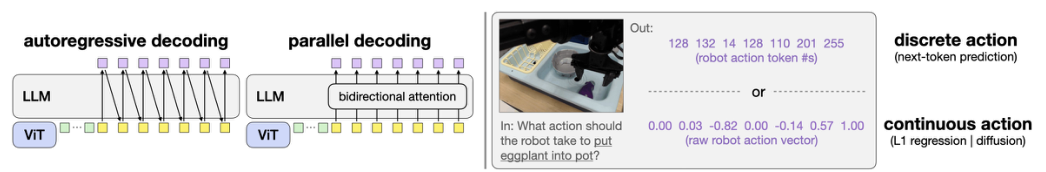

OFT, Figure 2: decoding and output choices, Kim et al. (2025). Original figure reproduced from the source; no redrawing. [Source](https://arxiv.org/abs/2502.19645).


[Pinned source, lines 736–745](https://github.com/moojink/openvla-oft/blob/e4287e94541f459edc4feabc4e181f537cd569a8/prismatic/extern/hf/modeling_prismatic.py#L736-L745)

```python
# Add (ACTION_DIM * NUM_ACTIONS_CHUNK) placeholder tokens to input_ids to simulate action tokens
placeholder_action_token_ids = (
    torch.ones((input_ids.shape[0], ACTION_DIM * NUM_ACTIONS_CHUNK)).to(input_ids.device).to(input_ids.dtype)
)
input_ids = torch.cat([input_ids, placeholder_action_token_ids], dim=-1)

# Add stop token to sequence (needed in non-causal bi-directional self-attention, as it appears at train time)
stop_token_id = torch.ones((input_ids.shape[0], 1)).to(input_ids.device).to(input_ids.dtype) * STOP_INDEX
input_ids = torch.cat([input_ids, stop_token_id], dim=-1)

```


[Pinned source, lines 889–915](https://github.com/moojink/openvla-oft/blob/e4287e94541f459edc4feabc4e181f537cd569a8/prismatic/extern/hf/modeling_prismatic.py#L889-L915)

```python
# Zero out action token embeddings
all_actions_mask = all_actions_mask.unsqueeze(-1)  # (B, seq_len, 1)
input_embeddings = input_embeddings * ~all_actions_mask

# Build multimodal embeddings and attention mask
multimodal_embeddings, multimodal_attention_mask = self._build_multimodal_attention(
    input_embeddings, projected_patch_embeddings, attention_mask
)

# Forward pass through language model
language_model_output = self.language_model(
    input_ids=None,
    attention_mask=multimodal_attention_mask,
    position_ids=None,
    past_key_values=None,
    inputs_embeds=multimodal_embeddings,
    labels=None,
    use_cache=None,
    output_attentions=False,
    output_hidden_states=True,
    return_dict=True,
)

# Extract hidden states for action tokens
last_hidden_states = language_model_output.hidden_states[-1]  # (B, seq_len, D)
actions_hidden_states = last_hidden_states[
    :,
```


[Pinned source, lines 719–732](https://github.com/moojink/transformers-openvla-oft/blob/bc339d9ad707454c0c115970db43c260067c61ab/src/transformers/models/llama/modeling_llama.py#L719-L732)

```python
if causal_mask is not None:
    D = causal_mask.shape[-1]
    last_row = causal_mask[:, :, -1, :].clone()
    new_mask = last_row.unsqueeze(2).expand(-1, -1, D, -1)
    causal_mask = new_mask

attn_output = torch.nn.functional.scaled_dot_product_attention(
    query_states,
    key_states,
    value_states,
    attn_mask=causal_mask,
    dropout_p=self.attention_dropout if self.training else 0.0,
    is_causal=False,
)
```


[Pinned source, lines 98–107](https://github.com/moojink/openvla-oft/blob/e4287e94541f459edc4feabc4e181f537cd569a8/prismatic/models/action_heads.py#L98-L107)

```python
def predict_action(self, actions_hidden_states):
    # actions_hidden_states: last hidden states of Transformer corresponding to action tokens in sequence
    # - shape: (batch_size, chunk_len * action_dim, hidden_dim)
    # ground_truth_actions: ground-truth actions
    # - shape: (batch_size, chunk_len, action_dim)
    batch_size = actions_hidden_states.shape[0]
    device = actions_hidden_states.device
    rearranged_actions_hidden_states = actions_hidden_states.reshape(batch_size, NUM_ACTIONS_CHUNK, -1)
    action = self.model(rearranged_actions_hidden_states)
    return action
```


### TO DO 1.2 — check parallel decoding
The pinned OFT SDPA implementation disables causal attention **for the whole sequence** and keeps padded key columns closed.
Reproduce this in `build_oft_attention_mask`. Our helper additionally zeros padded query outputs, which are discarded in the real model.
`True` means an allowed link; rows are queries, columns are input keys. Do not open padding.

Implement `probe_parallel_dependencies` for three cases: causal placeholders, OFT placeholders, OFT with true target inputs (wrong).
Run two independent interventions:

1. Change target `a[5]` and rebuild inputs. Placeholder inputs must stay identical; true-target inputs must change.
2. Perturb embedding slot `P+5` directly. The first action output may change only if that link is visible.

Return the specified table and per-position deltas. Use the same observations and block in all cases.
The toy omits OFT's stop token and uses a positional signal instead of RoPE; these probes preserve the dependency question.


In [ ]:
def build_oft_attention_mask(valid):
    # TO DO 1.2: reproduce full bidirectional attention while closing padding.
    raise NotImplementedError("Complete TO DO 1.2: mask")

def probe_parallel_dependencies(target, changed_token=5):
    # TO DO 1.2: compare causal placeholders, OFT placeholders and OFT true targets.
    # First edit target j and rebuild inputs; then independently perturb input slot P+j.
    # Return (DataFrame, deltas); deltas[name] has 'target' and 'slot' arrays.
    # DataFrame columns: configuration, target_change_at_first_action,
    # slot_change_at_first_action, padding_key_links, action_links.
    raise NotImplementedError("Complete TO DO 1.2: probe")


In [ ]:
oft_mask=build_oft_attention_mask(valid)
assert oft_mask.dtype==torch.bool and oft_mask.shape==(len(valid),len(valid))
assert not oft_mask[:,~valid].any() and not oft_mask[~valid,:].any()
assert oft_mask[valid][:,valid].all()
plot_masks({'Causal':causal_mask(valid),'OFT bidirectional':oft_mask})
parallel,deltas=probe_parallel_dependencies(TARGET)
display(parallel)
names=['causal placeholders','OFT placeholders','OFT true targets (wrong)']
for name in names[:2]:assert np.max(deltas[name]['target'])<1e-10
assert deltas[names[0]]['slot'][P]<1e-10
assert deltas[names[1]]['slot'][P]>1e-6
assert deltas[names[2]]['target'][P]>1e-6
assert (parallel['padding_key_links']==0).all()
# Changing a padded key must not affect any valid output.
x=make_inputs(TARGET,True);xp=x.clone();xp[-1]+=100
np.testing.assert_allclose(BLOCK(x,oft_mask)[valid].numpy(),BLOCK(xp,oft_mask)[valid].numpy(),atol=1e-10)
with torch.no_grad():chunk=CONTINUOUS_HEAD(BLOCK(x,oft_mask))
assert chunk.shape==(T_ATTENTION,D)
print('One-pass toy head shape:',tuple(chunk.shape), '| random weights: no quality claim')


**Question:** Locate input replacement, attention change and action head in the linked code.
Use the original Figure 2 to identify the sequential token-generation steps that disappear.
Why are causal placeholders free of target leakage but still different from OFT? Why does one forward pass say nothing about task success?


## 2. Scalar tokens and FAST+ — what survives encode/decode?
OFT changes prediction. FAST changes the representation while retaining autoregressive token prediction.
Here both tokenizers encode the **same recorded actions**; we evaluate reconstruction, not a trained policy.

The supplied encoder clips normalized values to `[-1,1]`, assigns each component to a uniform interval, and maps its index to an action token ID.
The decoder reverses the ID mapping and returns the interval center. This changes values even when no clipping occurs.
OpenVLA uses `bins` edges and `bins-1` centers; the last edge maps to the final center.
Increasing bins reduces quantization spacing, while the number of action tokens remains `T × D`.


[Original ActionTokenizer source](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/vla/action_tokenizer.py).


[Pinned source, lines 30–32](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/vla/action_tokenizer.py#L30-L32)

```python
# Create Uniform Bins + Compute Bin Centers
self.bins = np.linspace(min_action, max_action, self.n_bins)
self.bin_centers = (self.bins[:-1] + self.bins[1:]) / 2.0
```


[Pinned source, lines 40–46](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/vla/action_tokenizer.py#L40-L46)

```python
action = np.clip(action, a_min=float(self.min_action), a_max=float(self.max_action))
discretized_action = np.digitize(action, self.bins)

# Handle single element vs. batch
if len(discretized_action.shape) == 1:
    return self.tokenizer.decode(list(self.tokenizer.vocab_size - discretized_action))
else:
```


[Pinned source, lines 65–68](https://github.com/openvla/openvla/blob/c8f03f48af692657d3060c19588038c7220e9af9/prismatic/vla/action_tokenizer.py#L65-L68)

```python
discretized_actions = self.tokenizer.vocab_size - action_token_ids
discretized_actions = np.clip(discretized_actions - 1, a_min=0, a_max=self.bin_centers.shape[0] - 1)

return self.bin_centers[discretized_actions]
```


### TO DO 2.1 — compare scalar quantization errors
Implement `evaluate_scalar_tokenization(chunks, stats, bin_counts)` on the fixed test windows for 32, 64 and 256 edges.
Use the supplied `scalar_encode`, `scalar_decode`, normalization and `reconstruction_rows`.
Report per-channel physical MAE, maximum error and clipped fraction; token count is always `T × D`.
Separate **clipping error** (clipped input versus recorded action) from **quantization error** (decoded action versus clipped input).
These two MAEs need not add to total MAE. Compare gripper binary states and transition indices as well.
Read the error bars and residual plots: trajectory overlays can hide small differences.
The detail plots select one unclipped sample per signal type with the largest difference between methods; the summary uses all windows.


In [ ]:
def evaluate_scalar_tokenization(chunks, stats, bin_counts=(32,64,256)):
    # TO DO 2.1: normalize, encode/decode each bin count, restore physical units.
    # Use reconstruction_rows; method names must be 'OpenVLA 32', 'OpenVLA 64', 'OpenVLA 256'.
    # Return a DataFrame. Count action tokens as T*D for every chunk.
    raise NotImplementedError("Complete TO DO 2.1")


In [ ]:
chunks=get_chunks(20)
scalar_table=evaluate_scalar_tokenization(chunks,STATS,(32,64,256))
assert set(scalar_table['method'])=={'OpenVLA 32','OpenVLA 64','OpenVLA 256'}
assert (scalar_table['tokens']==20*7).all()
assert scalar_table['clipped_fraction'].between(0,1).all()
assert scalar_table['gripper_states_preserved'].all()
show_tables(scalar_table)
z=normalize(chunks,STATS)
restored=[denormalize(scalar_decode(scalar_encode(z,b),b),STATS) for b in (32,64,256)]
scalar_summary=show_quantization_errors(scalar_table,20,'scalar_quantization_errors.png')
scalar_examples=plot_quantization_details(chunks,restored,['32 edges','64 edges','256 edges'],STATS,
    'scalar_quantization_details.png')
# Endpoint behavior must match the upstream implementation.
assert scalar_decode(scalar_encode(np.array([-1.,1.]),256),256)[1] < 1
scalar_table.to_csv(ROOT/'scalar_metrics.csv',index=False)


**Question:** How does quantization MAE change across 32, 64 and 256 edges? Use the residual plots to explain why trajectory overlays can look identical. Which channels suffer clipping, and can more bins recover clipped values?


### FAST+: compress the chunk in frequency space
DCT converts each channel over time into frequency coefficients. Rounding scaled coefficients introduces reconstruction error.
Flattening puts low-frequency coefficients first. BPE packs recurring coefficient strings into variable-length token sequences.
BPE is lossless for supported strings; the DCT quantization and coefficient range handling can lose information.
A sudden change spreads energy across frequencies, so smoothness can affect token length.
FAST+ is the pretrained universal tokenizer; we do not fit BPE on test actions.


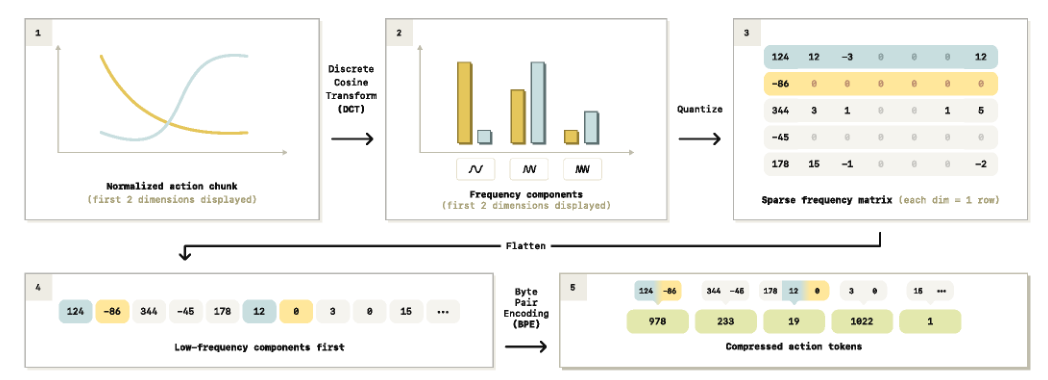

FAST, Figure 4: tokenization pipeline, Pertsch et al. (2025). Original figure reproduced from the source; no redrawing. [Source](https://www.roboticsproceedings.org/rss21/p012.pdf).


[Pinned official FAST+ source and tokenizer](https://huggingface.co/physical-intelligence/fast/tree/ec4d7aa71691cac0b8bed6942be45684db2110f4) · revision `ec4d7aa71691cac0b8bed6942be45684db2110f4`


```python
dct_coeff = dct(action_chunk, axis=1, norm="ortho")
dct_coeff = np.around(dct_coeff * self.scale)
tokens = []
for elem in dct_coeff:
    token_str = "".join(map(chr, np.maximum(elem.flatten() - self.min_token, 0).astype(int)))
    tokens.append(self.bpe_tokenizer(token_str)["input_ids"])
return tokens
```


### TO DO 2.2 — compare compression and reconstruction
Implement `compare_chunk_encodings`: normalize once, run OpenVLA 256 and FAST+ on identical chunks, and restore physical units.
The supplied `fast_roundtrip` checks the BPE string and calls official `decode(..., time_horizon=T, action_dim=D)` explicitly.
Count only action IDs, without prompt tokens or EOS. Report `T × D / N_FAST`, channel errors and gripper events.
Compare reconstruction error after shared clipping alongside token count; use mm/step and deg/step for readable plots.

Repeat for **T = 5, 10, 20** (1, 2, 4 s at 5 Hz). The authors' typical FAST+ horizon is about one second; longer chunks are a diagnostic.
Do not assume FAST+ is shorter or more accurate on every window. Find a short gripper segment or abrupt movement where MAE hides a larger local error.
If all recorded gripper transitions survive, report that result; do not invent a lost event.


In [ ]:
def compare_chunk_encodings(chunks, stats, fast_tokenizer):
    # TO DO 2.2: compare OpenVLA 256 and FAST+ on the SAME normalized chunks.
    # Use fast_roundtrip (strict BPE check; decode with explicit T,D) and reconstruction_rows.
    # Return a DataFrame with method names 'OpenVLA 256' and 'FAST+'.
    raise NotImplementedError("Complete TO DO 2.2")


In [ ]:
comparison=pd.concat([compare_chunk_encodings(get_chunks(T),STATS,fast_tokenizer) for T in (5,10,20)],ignore_index=True)
assert set(comparison['T'])=={5,10,20}
assert set(comparison['method'])=={'OpenVLA 256','FAST+'}
assert (comparison['tokens']>0).all()
show_tables(comparison)
per_chunk=comparison.drop_duplicates(['method','T','episode','kind','start'])
display(per_chunk[['episode','kind','T','method','tokens','ratio','event_count','true_events','decoded_events','gripper_states_preserved']])
tokens,decoded=fast_roundtrip(normalize(chunks,STATS))
fast_restored=denormalize(decoded,STATS)
fast_summary=show_quantization_errors(comparison,20,'fast_quantization_errors.png')
fast_examples=plot_quantization_details(chunks,[restored[-1],fast_restored],['OpenVLA 256','FAST+'],STATS,
    'fast_quantization_details.png')
plot_token_counts(comparison,'action_token_counts.png')
comparison.to_csv(ROOT/'comparison_metrics.csv',index=False)


In [ ]:
# Look for a short, actually recorded gripper state segment (including window boundaries).
candidates=[]
for b in range(len(chunks)):
    edges=np.r_[0,transitions(chunks[b,:,-1]),len(chunks[b])]
    for left,right in zip(edges[:-1],edges[1:]):
        candidates.append((right-left,b,int(left),int(right)))
width,b,left,right=min(candidates)
print('Shortest recorded gripper segment:',width,'steps =',width/HZ,'s',
      '|',TEST_WINDOWS[b]['key'],TEST_WINDOWS[b]['kind'],'| indices',left,right)
print('This segment touches a chunk boundary; its full episode duration is not measured here.')
err=np.abs(fast_restored[b]-chunks[b])
display(pd.DataFrame({'channel':CHANNELS,'MAE':err.mean(0),'max_error':err.max(0)}))
print('Gripper events:',event_metrics(chunks[b],fast_restored[b]))
plot_reconstruction(chunks,[restored[-1],fast_restored],['OpenVLA 256','FAST+'],[b])


**Question:** Use measured token counts and errors to compare a smooth and a correction window.
Name the short segment above, report its event preservation, and explain why channel MAE alone cannot certify a transition time.
Distinguish quantization loss from BPE compression.


## Sources and reproducibility
Original figures are embedded in notebook attachments; they are not redrawn.
The Bridge archive and FAST+ files are embedded with SHA-256 checks. `MANIFEST` includes per-record hashes and source paths.
`scalar_metrics.csv` and `comparison_metrics.csv` are written under the printed runtime directory.
Teacher outputs are generated on CPU; a hosted Colab run is a separate check.

| Source | Pinned revision |
|---|---|
| openvla | `c8f03f48af692657d3060c19588038c7220e9af9` |
| oft | `e4287e94541f459edc4feabc4e181f537cd569a8` |
| transformers | `bc339d9ad707454c0c115970db43c260067c61ab` |
| fast | `ec4d7aa71691cac0b8bed6942be45684db2110f4` |

[OpenVLA project / paper](https://openvla.github.io/) · [OFT project / paper](https://openvla-oft.github.io/) ·
[FAST paper](https://www.roboticsproceedings.org/rss21/p012.pdf) · [FAST+ code](https://huggingface.co/physical-intelligence/fast) ·
[BridgeData V2](https://rail-berkeley.github.io/bridgedata/).
Code excerpts retain upstream authorship; OpenVLA/OFT use MIT, the Transformers fork Apache 2.0, and FAST+ Apache 2.0.
Figure attribution is included below each original image.
